# Notebook 4 — Ejecucion y costes

N4 transforma la cartera objetivo de N3 en resultados invertibles: aplica reglas de ejecucion cronologica, comisiones y control de excepciones operativas. Este notebook contiene el motor de simulacion que recorre el calendario bursatil dia a dia ejecutando tres bloques — asignacion inicial, rebalanceos mensuales y eventos forzosos — y registra cada orden, cada comision y cada excepcion para que N5 pueda analizar rendimiento sin ambiguedad operacional.

**Reglas del enunciado que implementa N4:** compras iniciales al CLOSE (dimensionadas con OPEN del mismo dia), salidas de rebalanceo al OPEN, entradas de rebalanceo al CLOSE (dimensionadas con OPEN del dia), comision proporcional (0.23%) con minimo por orden (23 USD), acciones enteras (sin fracciones), salidas forzosas por exclusion del S&P 500 al CLOSE, y una politica de reweight que recorta sobrepesos antes de comprar.

**Artefactos que produce N4:**

| Artefacto | Descripcion | Consumido por |
|---|---|---|
| `n4_orders_log.csv` | Registro de cada orden ejecutada o rechazada | N5, Auditoria |
| `n4_portfolio_daily.csv` | Equity, cash y market value diarios | N5 |
| `n4_rebalance_summary.csv` | Resumen operativo por fecha de rebalanceo | N5 |
| `n4_cost_summary.csv` | Desglose total de comisiones por tipo | N5 |
| `n4_checks.csv` | Registro de validaciones del motor | Auditoria |

---

## 1. Configuracion

Se importan librerias, se definen rutas de entrada y salida, y se declaran los parametros operativos del enunciado. Las funciones auxiliares (`calc_fee`, `max_affordable_notional`, `integer_buy_ticket`) encapsulan la logica de comisiones y ejecucion en acciones enteras para que el motor principal las invoque sin duplicar codigo.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

# --- Entradas ---
N1_RUNTIME  = "data/processed/n1_runtime_params.csv"
N2_EXEC     = "data/processed/n2_execution_prices.parquet"
N3_SELECTED = "data/processed/n3_selected_assets.csv"
N3_INITIAL  = "data/processed/n3_initial_allocation.csv"
CANONICAL   = "data/processed/sp500_canonical.parquet"

# --- Salidas ---
OUT_ORDERS    = "data/processed/n4_orders_log.csv"
OUT_DAILY     = "data/processed/n4_portfolio_daily.csv"
OUT_REBALANCE = "data/processed/n4_rebalance_summary.csv"
OUT_COSTS     = "data/processed/n4_cost_summary.csv"
OUT_CHECKS    = "data/processed/n4_checks.csv"

# --- Parametros operativos ---
TOP_N = 20
TARGET_WEIGHT = 0.05
TARGET_WEIGHT_MIN = 0.049
TARGET_WEIGHT_MAX = 0.051


def fail_if(condition, message):
    if condition:
        raise ValueError(message)

checks = []

def check(name, passed, details, critical=True):
    checks.append({"check": name, "passed": passed, "critical": critical, "details": details})
    fail_if(critical and not passed, f"[{name}] {details}")


def to_float(value, default):
    try:
        return float(value)
    except Exception:
        return float(default)


def calc_fee(notional, fee_rate, fee_min):
    return float(max(abs(notional) * fee_rate, fee_min))


def max_affordable_notional(cash, fee_rate, fee_min):
    if cash <= fee_min:
        return 0.0
    threshold = fee_min / fee_rate
    affordable = cash - fee_min
    if affordable <= threshold:
        return max(affordable, 0.0)
    return cash / (1.0 + fee_rate)

print("Configuracion lista.")

Configuracion lista.


---

## 2. Carga y validacion de inputs

Se cargan los artefactos de N1, N2 y N3 necesarios para la simulacion: los parametros de ejecucion, los precios de ejecucion con flags de elegibilidad, las carteras seleccionadas (mensual + inicial), y el dataset canonico para valoracion diaria y deteccion de exclusiones del indice. Las columnas booleanas se reconvierten explicitamente desde CSV y se verifica que las cardinalidades y fechas operativas sean coherentes antes de simular.

In [2]:
# Carga de artefactos
for path in [N1_RUNTIME, N2_EXEC, N3_SELECTED, N3_INITIAL, CANONICAL]:
    fail_if(not pd.io.common.file_exists(path), f"No existe: {path}")

runtime_params = dict(zip(*pd.read_csv(N1_RUNTIME)[["parameter", "value"]].values.T))
initial_capital = to_float(runtime_params.get("initial_capital", "250000"), 250000.0)
fee_rate = to_float(runtime_params.get("transaction_fee_rate", "0.0023"), 0.0023)
fee_min = to_float(runtime_params.get("min_fee_per_order", "23.0"), 23.0)
backtest_start = pd.Timestamp(runtime_params.get("backtest_start", "2015-01-01"))

selected_monthly = pd.read_csv(N3_SELECTED)
initial_alloc = pd.read_csv(N3_INITIAL)
execution_df = pd.read_parquet(N2_EXEC, engine="pyarrow")
canonical_df = pd.read_parquet(CANONICAL, columns=["date", "symbol", "open", "close", "in_sp500"], engine="pyarrow")

# Tipado robusto
for df_ref in [selected_monthly, initial_alloc]:
    df_ref["rebalance_date"] = pd.to_datetime(df_ref["rebalance_date"])
    df_ref["symbol"] = df_ref["symbol"].astype("string")
execution_df["rebalance_date"] = pd.to_datetime(execution_df["rebalance_date"])
execution_df["symbol"] = execution_df["symbol"].astype("string")
canonical_df["date"] = pd.to_datetime(canonical_df["date"])
canonical_df["symbol"] = canonical_df["symbol"].astype("string")

# Reconversion booleanos desde CSV
for col in ["is_initial_allocation"]:
    for df_ref in [selected_monthly, initial_alloc]:
        if col not in df_ref.columns:
            df_ref[col] = col == "is_initial_allocation" and df_ref is initial_alloc
        elif df_ref[col].dtype != bool:
            df_ref[col] = df_ref[col].astype("string").str.lower().map({"true": True, "false": False})

# Contrato operativo: mensual sin fila inicial, inicial con flag True
selected_monthly["is_initial_allocation"] = False
initial_alloc["is_initial_allocation"] = True

selected_df = pd.concat([initial_alloc, selected_monthly], ignore_index=True)
selected_df = selected_df.sort_values(["rebalance_date", "rank", "symbol"]).reset_index(drop=True)

# Validaciones
check("columnas_seleccion",
      {"rebalance_date", "symbol", "rank", "target_weight", "is_initial_allocation"}.issubset(selected_df.columns),
      f"faltan columnas en selected")
check("unicidad_seleccion", int(selected_df.duplicated(["rebalance_date", "symbol"]).sum()) == 0,
      f"duplicados={int(selected_df.duplicated(['rebalance_date', 'symbol']).sum())}")

counts = selected_df.groupby("rebalance_date")["symbol"].size()
check("20_por_fecha", int((counts != TOP_N).sum()) == 0, f"fechas!={TOP_N}: {int((counts != TOP_N).sum())}")

weights = selected_df.groupby("rebalance_date")["target_weight"].sum()
bad_weights = int((~np.isclose(weights, 1.0)).sum())
check("pesos_suman_1", bad_weights == 0, f"fechas_bad={bad_weights}")

initial_dates = selected_df.loc[selected_df["is_initial_allocation"], "rebalance_date"].drop_duplicates()
check("asignacion_inicial_unica", len(initial_dates) == 1, f"n={len(initial_dates)}")
initial_allocation_date = initial_dates.min()

check("columnas_ejecucion",
      {"rebalance_date", "symbol", "open_rebalance", "close_rebalance"}.issubset(execution_df.columns),
      "faltan columnas en execution_df")
if "eligible_for_execution" not in execution_df.columns:
    execution_df["eligible_for_execution"] = (
        execution_df["open_rebalance"].gt(0) & execution_df["close_rebalance"].gt(0)
    )
check("fee_rate", np.isclose(fee_rate, 0.0023), f"fee_rate={fee_rate}")
check("fee_min", np.isclose(fee_min, 23.0), f"fee_min={fee_min}")
check("no_fines_de_semana", int((canonical_df["date"].dt.dayofweek >= 5).sum()) == 0,
      f"weekend_rows={int((canonical_df['date'].dt.dayofweek >= 5).sum())}")

# Fechas operativas
all_signal_dates = pd.Index(selected_df["rebalance_date"].drop_duplicates().sort_values())
monthly_rebalance_dates = all_signal_dates[all_signal_dates != initial_allocation_date]

check(
    "inicial_en_mes_backtest_start",
    initial_allocation_date.to_period("M") == backtest_start.to_period("M"),
    f"inicial={initial_allocation_date.date()} start={backtest_start.date()}",
)
check("primer_rebalanceo_post_start", monthly_rebalance_dates.min() >= backtest_start,
      f"primer={monthly_rebalance_dates.min().date()}")

print(f"Capital inicial:     ${initial_capital:,.0f}")
print(f"Fee rate:            {fee_rate:.4f} (min ${fee_min})")
print(f"Asignacion inicial:  {initial_allocation_date.date()}")
print(f"Rebalanceos:         {len(monthly_rebalance_dates)} (primer: {monthly_rebalance_dates.min().date()})")

Capital inicial:     $250,000
Fee rate:            0.0023 (min $23.0)
Asignacion inicial:  2015-01-30
Rebalanceos:         132 (primer: 2015-02-27)


### Convencion temporal de ejecucion (sin anticipacion intradia)
Las senales y el ranking se construyen con informacion historica laggeada (N3).
En rebalanceo, las salidas completas se ejecutan al OPEN y las entradas al CLOSE.

Para evitar decidir con el cierre final del dia:
- El reweight de venta se dimensiona con CLOSE t-1 y se ejecuta al OPEN t.
- Las compras se dimensionan con OPEN t (y caja real tras ventas) y se ejecutan al CLOSE t.

El 5% se trata como objetivo de diseno. Por fricciones de mercado, comisiones
y acciones enteras, se evalua cumplimiento en banda 4.9%-5.1%.


In [3]:
# Motor de simulacion parametrico para comparar politica con/sin reweight.
def run_backtest(
    selected_df: pd.DataFrame,
    execution_df: pd.DataFrame,
    canonical_df: pd.DataFrame,
    initial_capital: float,
    fee_rate: float,
    fee_min: float,
    initial_allocation_date: pd.Timestamp,
    monthly_rebalance_dates: pd.Index,
    enable_reweight: bool,
) -> dict:
    """Ejecuta el backtest con politica configurable de rebalanceo."""
    execution_lookup = execution_df.set_index(["rebalance_date", "symbol"])
    selected_by_date = {
        dt: frame.sort_values("rank").reset_index(drop=True)
        for dt, frame in selected_df.groupby("rebalance_date", observed=True)
    }

    canonical_core = canonical_df.sort_values(["date", "symbol"]).reset_index(drop=True)
    close_lookup = canonical_core.set_index(["date", "symbol"])["close"]
    open_lookup = canonical_core.set_index(["date", "symbol"])["open"]
    in_sp_lookup = canonical_core.set_index(["date", "symbol"])["in_sp500"]
    canonical_core["in_sp500_prev"] = (
        canonical_core.groupby("symbol", observed=True)["in_sp500"].shift(1)
    )
    in_sp_prev_lookup = canonical_core.set_index(["date", "symbol"])["in_sp500_prev"]

    all_trading_dates = pd.Index(canonical_core["date"].drop_duplicates().sort_values())
    trading_dates = all_trading_dates[
        (all_trading_dates >= initial_allocation_date)
        & (all_trading_dates <= monthly_rebalance_dates.max())
    ]

    cash = float(initial_capital)
    positions = {}
    last_close_cache = {}
    last_seen_close = {}
    last_seen_date = {}

    orders_rows = []
    daily_rows = []
    position_snapshot_rows = []
    open_fallback_count = 0
    monthly_rebalance_set = set(monthly_rebalance_dates.tolist())

    def _append_order(
        trade_date,
        symbol,
        side,
        reason,
        status,
        price_type,
        price,
        shares,
        notional,
        fee,
        cash_after,
        proxy_price_date=None,
    ):
        orders_rows.append(
            {
                "date": trade_date,
                "symbol": symbol,
                "side": side,
                "reason": reason,
                "status": status,
                "price_type": price_type,
                "price": float(price),
                "shares": float(shares),
                "notional": float(notional),
                "fee": float(fee),
                "cash_after": float(cash_after),
                "proxy_price_date": proxy_price_date,
                "policy_mode": "with_reweight" if enable_reweight else "without_reweight",
            }
        )

    def _get_open_reference(trade_date, symbol):
        """Precio observable al inicio de sesion para decidir tamanos."""
        exec_key = (trade_date, symbol)
        if exec_key in execution_lookup.index:
            return float(execution_lookup.loc[exec_key, "open_rebalance"]), False
        return float(open_lookup.get(exec_key, np.nan)), True

    def _shares_from_reference_price(reference_price, target_notional):
        if (not np.isfinite(reference_price)) or (reference_price <= 0):
            return 0
        if target_notional <= 0:
            return 0
        return int(np.floor(float(target_notional) / float(reference_price)))

    def _integer_buy_from_shares(exec_price, desired_shares, cash_available):
        """Compra entera: fija max acciones objetivo y recorta por caja/comision."""
        if (not np.isfinite(exec_price)) or (exec_price <= 0):
            return 0, 0.0, 0.0

        shares = int(max(desired_shares, 0))
        while shares > 0:
            notional = float(shares * exec_price)
            fee = float(calc_fee(notional, fee_rate, fee_min))
            if notional + fee <= cash_available + 1e-9:
                return shares, notional, fee
            shares -= 1
        return 0, 0.0, 0.0

    def _execute_initial_allocation(trade_date):
        nonlocal cash, open_fallback_count
        target_df = selected_by_date[trade_date]
        target_notional_per_entry = TARGET_WEIGHT * cash

        for _, row in target_df.iterrows():
            symbol = row["symbol"]
            exec_key = (trade_date, symbol)

            if exec_key in execution_lookup.index:
                close_px = float(execution_lookup.loc[exec_key, "close_rebalance"])
            else:
                close_px = float(close_lookup.get(exec_key, np.nan))

            decision_px, used_fallback = _get_open_reference(trade_date, symbol)
            if used_fallback:
                open_fallback_count += 1

            # Inicial: decide con OPEN, ejecuta al CLOSE.
            eligible_exec = (
                np.isfinite(close_px)
                and (close_px > 0)
                and np.isfinite(decision_px)
                and (decision_px > 0)
            )
            if not eligible_exec:
                _append_order(
                    trade_date,
                    symbol,
                    "buy",
                    "initial_allocation",
                    "no_fill_non_executable",
                    "close_initial",
                    close_px if np.isfinite(close_px) else np.nan,
                    0.0,
                    0.0,
                    0.0,
                    float(cash),
                )
                continue

            desired_shares = _shares_from_reference_price(
                decision_px,
                target_notional_per_entry,
            )
            shares, trade_notional, fee = _integer_buy_from_shares(
                close_px,
                desired_shares,
                cash,
            )
            if shares <= 0:
                _append_order(
                    trade_date,
                    symbol,
                    "buy",
                    "initial_allocation",
                    "no_fill_cash",
                    "close_initial",
                    close_px,
                    0.0,
                    0.0,
                    0.0,
                    float(cash),
                )
                continue

            fail_if(
                trade_notional + fee - cash > 1e-6,
                f"Initial allocation con cash insuficiente: {trade_date.date()} {symbol}",
            )
            cash -= trade_notional + fee
            positions[symbol] = int(positions.get(symbol, 0) + shares)
            last_close_cache[symbol] = float(close_px)

            _append_order(
                trade_date,
                symbol,
                "buy",
                "initial_allocation",
                "filled",
                "close_initial",
                close_px,
                float(shares),
                float(trade_notional),
                float(fee),
                float(cash),
            )

    def _execute_rebalance(trade_date):
        nonlocal cash, open_fallback_count
        target_df = selected_by_date[trade_date]
        target_symbols = set(target_df["symbol"])
        held_symbols = set(positions.keys())

        # B.1) Salidas al OPEN
        exit_symbols = sorted(held_symbols - target_symbols)
        for symbol in exit_symbols:
            exec_key = (trade_date, symbol)

            if exec_key in execution_lookup.index:
                open_px = float(execution_lookup.loc[exec_key, "open_rebalance"])
            else:
                open_px = float(open_lookup.get(exec_key, np.nan))
                open_fallback_count += 1

            if (not np.isfinite(open_px)) or (open_px <= 0):
                proxy_px = last_seen_close.get(symbol, np.nan)
                proxy_date = last_seen_date.get(symbol, pd.NaT)
                fail_if(
                    pd.isna(proxy_px) or (float(proxy_px) <= 0) or pd.isna(proxy_date),
                    f"Salida rebalance sin OPEN ni proxy: {trade_date.date()} {symbol}",
                )

                shares = positions.pop(symbol)
                notional = shares * float(proxy_px)
                fee = calc_fee(notional, fee_rate, fee_min)
                cash += notional - fee

                _append_order(
                    trade_date,
                    symbol,
                    "sell",
                    "forced_exit_no_quote_proxy",
                    "filled",
                    "close_proxy_last_seen",
                    float(proxy_px),
                    float(shares),
                    float(notional),
                    float(fee),
                    float(cash),
                    proxy_date,
                )

                last_close_cache.pop(symbol, None)
                last_seen_close.pop(symbol, None)
                last_seen_date.pop(symbol, None)
                continue

            shares = positions.pop(symbol)
            notional = shares * open_px
            fee = calc_fee(notional, fee_rate, fee_min)
            cash += notional - fee

            _append_order(
                trade_date,
                symbol,
                "sell",
                "rebalance_exit",
                "filled",
                "open_rebalance",
                open_px,
                float(shares),
                float(notional),
                float(fee),
                float(cash),
            )

            last_close_cache.pop(symbol, None)
            last_seen_close.pop(symbol, None)
            last_seen_date.pop(symbol, None)

        # B.2) Precios de ejecucion (CLOSE) y referencias de decision (OPEN y CLOSE t-1)
        close_by_symbol = {}
        eligible_exec_by_symbol = {}
        for symbol in sorted(target_symbols):
            exec_key = (trade_date, symbol)
            if exec_key in execution_lookup.index:
                exec_row = execution_lookup.loc[exec_key]
                close_px = float(exec_row["close_rebalance"])
                eligible_exec = bool(exec_row["eligible_for_execution"])
            else:
                close_px = float(close_lookup.get(exec_key, np.nan))
                eligible_exec = False

            fail_if(
                pd.isna(close_px) or (close_px <= 0),
                f"CLOSE invalido en rebalance para target: {trade_date.date()} {symbol}",
            )
            close_by_symbol[symbol] = float(close_px)
            eligible_exec_by_symbol[symbol] = eligible_exec

        prev_idx = int(trading_dates.get_loc(trade_date)) - 1
        prev_trade_date = trading_dates[prev_idx] if prev_idx >= 0 else pd.NaT

        decision_symbols = sorted(target_symbols.union(set(positions.keys())))
        decision_open_by_symbol = {}
        open_exec_by_symbol = {}
        decision_prev_close_by_symbol = {}

        for symbol in decision_symbols:
            open_px, used_fallback = _get_open_reference(trade_date, symbol)
            if used_fallback:
                open_fallback_count += 1

            if np.isfinite(open_px) and (open_px > 0):
                open_exec_by_symbol[symbol] = float(open_px)
                decision_open_by_symbol[symbol] = float(open_px)
            else:
                proxy_px = last_seen_close.get(symbol, np.nan)
                if pd.notna(proxy_px) and float(proxy_px) > 0:
                    decision_open_by_symbol[symbol] = float(proxy_px)

            prev_close_px = np.nan
            if pd.notna(prev_trade_date):
                prev_close_px = close_lookup.get((prev_trade_date, symbol), np.nan)
            if pd.notna(prev_close_px) and float(prev_close_px) > 0:
                decision_prev_close_by_symbol[symbol] = float(prev_close_px)
            else:
                proxy_prev = last_seen_close.get(symbol, np.nan)
                if pd.notna(proxy_prev) and float(proxy_prev) > 0:
                    decision_prev_close_by_symbol[symbol] = float(proxy_prev)

        # B.3) Reweight de venta: decide con CLOSE t-1 y ejecuta al OPEN t.
        if enable_reweight:
            equity_ref_prev_close = float(cash)
            for symbol, shares in positions.items():
                ref_px = decision_prev_close_by_symbol.get(symbol, np.nan)
                fail_if(
                    pd.isna(ref_px) or (float(ref_px) <= 0),
                    f"Sin CLOSE t-1 para reweight: {trade_date.date()} {symbol}",
                )
                equity_ref_prev_close += float(shares) * float(ref_px)

            target_notional_sell = TARGET_WEIGHT * equity_ref_prev_close

            for symbol in sorted(target_symbols):
                prev_close_px = decision_prev_close_by_symbol.get(symbol, np.nan)
                open_exec_px = open_exec_by_symbol.get(symbol, np.nan)
                if pd.isna(prev_close_px) or (float(prev_close_px) <= 0):
                    continue
                if pd.isna(open_exec_px) or (float(open_exec_px) <= 0):
                    _append_order(
                        trade_date,
                        symbol,
                        "sell",
                        "rebalance_reweight",
                        "no_fill_non_executable",
                        "open_rebalance",
                        np.nan,
                        0.0,
                        0.0,
                        0.0,
                        float(cash),
                    )
                    continue

                current_shares = int(positions.get(symbol, 0))
                current_notional_prev = current_shares * float(prev_close_px)
                delta = target_notional_sell - current_notional_prev
                if delta >= -1e-9:
                    continue

                trim = min(-delta, current_notional_prev)
                if trim <= 0:
                    continue

                shares_to_sell = min(
                    int(np.floor(trim / float(prev_close_px))),
                    int(current_shares),
                )
                if shares_to_sell <= 0:
                    continue

                sell_notional = float(shares_to_sell * float(open_exec_px))
                fee = calc_fee(sell_notional, fee_rate, fee_min)
                remaining = int(current_shares - shares_to_sell)

                if remaining <= 0:
                    positions.pop(symbol, None)
                else:
                    positions[symbol] = remaining

                cash += sell_notional - fee
                _append_order(
                    trade_date,
                    symbol,
                    "sell",
                    "rebalance_reweight",
                    "filled",
                    "open_rebalance",
                    float(open_exec_px),
                    float(shares_to_sell),
                    float(sell_notional),
                    float(fee),
                    float(cash),
                )

        # B.4) Compras: decide con OPEN t y caja real tras ventas; ejecuta al CLOSE t.
        equity_ref_open = float(cash)
        for symbol, shares in positions.items():
            ref_px = decision_open_by_symbol.get(symbol, np.nan)
            fail_if(
                pd.isna(ref_px) or (float(ref_px) <= 0),
                f"Sin precio OPEN para compra/reweight: {trade_date.date()} {symbol}",
            )
            equity_ref_open += float(shares) * float(ref_px)

        target_notional_buy = TARGET_WEIGHT * equity_ref_open

        for symbol in sorted(target_symbols):
            close_px = close_by_symbol[symbol]
            decision_px = decision_open_by_symbol.get(symbol, np.nan)

            if enable_reweight:
                if pd.isna(decision_px) or float(decision_px) <= 0:
                    _append_order(
                        trade_date,
                        symbol,
                        "buy",
                        "rebalance_entry",
                        "no_fill_non_executable",
                        "close_rebalance",
                        close_px,
                        0.0,
                        0.0,
                        0.0,
                        float(cash),
                    )
                    continue

                current_shares = int(positions.get(symbol, 0))
                current_notional_ref = current_shares * float(decision_px)
                delta = target_notional_buy - current_notional_ref
                if delta <= 1e-9:
                    continue
            else:
                if symbol in positions:
                    continue
                delta = target_notional_buy

            if not eligible_exec_by_symbol.get(symbol, False):
                _append_order(
                    trade_date,
                    symbol,
                    "buy",
                    "rebalance_entry",
                    "no_fill_non_executable",
                    "close_rebalance",
                    close_px,
                    0.0,
                    0.0,
                    0.0,
                    float(cash),
                )
                continue

            desired_shares = _shares_from_reference_price(decision_px, delta)
            shares, trade_notional, fee = _integer_buy_from_shares(
                close_px,
                desired_shares,
                cash,
            )

            if shares <= 0:
                _append_order(
                    trade_date,
                    symbol,
                    "buy",
                    "rebalance_entry",
                    "no_fill_cash",
                    "close_rebalance",
                    close_px,
                    0.0,
                    0.0,
                    0.0,
                    float(cash),
                )
                continue

            fail_if(
                trade_notional + fee - cash > 1e-6,
                f"Compra con cash insuficiente: {trade_date.date()} {symbol}",
            )

            cash -= trade_notional + fee
            positions[symbol] = int(positions.get(symbol, 0) + shares)
            last_close_cache[symbol] = float(close_px)
            last_seen_close[symbol] = float(close_px)
            last_seen_date[symbol] = trade_date

            _append_order(
                trade_date,
                symbol,
                "buy",
                "rebalance_entry",
                "filled",
                "close_rebalance",
                close_px,
                float(shares),
                float(trade_notional),
                float(fee),
                float(cash),
            )

    def _execute_forced_exits(trade_date):
        nonlocal cash
        for symbol in list(positions.keys()):
            close_px = close_lookup.get((trade_date, symbol), np.nan)
            has_valid_close = pd.notna(close_px) and (float(close_px) > 0)

            if has_valid_close:
                close_px = float(close_px)
                last_close_cache[symbol] = close_px
                last_seen_close[symbol] = close_px
                last_seen_date[symbol] = trade_date

                prev_in = in_sp_prev_lookup.get((trade_date, symbol), np.nan)
                curr_in = in_sp_lookup.get((trade_date, symbol), np.nan)
                if (prev_in == 1) and (curr_in == 0):
                    shares = positions.pop(symbol)
                    notional = shares * close_px
                    fee = calc_fee(notional, fee_rate, fee_min)
                    cash += notional - fee

                    _append_order(
                        trade_date,
                        symbol,
                        "sell",
                        "forced_exit",
                        "filled",
                        "close_event",
                        close_px,
                        float(shares),
                        float(notional),
                        float(fee),
                        float(cash),
                    )

                    last_close_cache.pop(symbol, None)
                    last_seen_close.pop(symbol, None)
                    last_seen_date.pop(symbol, None)
                continue

            # Sin cotizacion: salida forzosa con proxy
            proxy_px = last_seen_close.get(symbol, np.nan)
            proxy_date = last_seen_date.get(symbol, pd.NaT)
            fail_if(
                pd.isna(proxy_px) or (float(proxy_px) <= 0) or pd.isna(proxy_date),
                f"No hay close ni proxy para salida forzosa: {trade_date.date()} {symbol}",
            )

            shares = positions.pop(symbol)
            notional = shares * float(proxy_px)
            fee = calc_fee(notional, fee_rate, fee_min)
            cash += notional - fee

            _append_order(
                trade_date,
                symbol,
                "sell",
                "forced_exit_no_quote_proxy",
                "filled",
                "close_proxy_last_seen",
                float(proxy_px),
                float(shares),
                float(notional),
                float(fee),
                float(cash),
                proxy_date,
            )

            last_close_cache.pop(symbol, None)
            last_seen_close.pop(symbol, None)
            last_seen_date.pop(symbol, None)

    def _mark_to_market(trade_date, is_monthly_rebalance_day, is_initial_allocation_day):
        market_value = 0.0
        missing_prices = []
        valuation_rows = []
        for symbol, shares in positions.items():
            close_px = close_lookup.get((trade_date, symbol), np.nan)
            if pd.notna(close_px) and (close_px > 0):
                last_close_cache[symbol] = float(close_px)
                px = float(close_px)
            else:
                px = last_close_cache.get(symbol, np.nan)

            if pd.isna(px) or (px <= 0):
                missing_prices.append(symbol)
                continue

            notional = float(shares) * float(px)
            market_value += notional
            valuation_rows.append(
                {
                    "date": trade_date,
                    "symbol": symbol,
                    "shares": float(shares),
                    "price_for_valuation": float(px),
                    "position_notional": float(notional),
                    "is_rebalance": bool(is_monthly_rebalance_day),
                    "is_initial_allocation": bool(is_initial_allocation_day),
                }
            )

        fail_if(
            len(missing_prices) > 0,
            f"Sin precio para posiciones vivas en {trade_date.date()}: {missing_prices[:10]}",
        )

        equity = cash + market_value
        fail_if(equity < -1e-6, f"Equity negativo en {trade_date.date()}: {equity}")

        daily_rows.append(
            {
                "date": trade_date,
                "is_rebalance": bool(is_monthly_rebalance_day),
                "is_initial_allocation": bool(is_initial_allocation_day),
                "cash": float(cash),
                "market_value": float(market_value),
                "equity": float(equity),
                "n_positions": int(len(positions)),
            }
        )
        position_snapshot_rows.extend(valuation_rows)

    for trade_date in trading_dates:
        is_initial_allocation_day = trade_date == initial_allocation_date
        is_monthly_rebalance_day = trade_date in monthly_rebalance_set

        if is_initial_allocation_day:
            _execute_initial_allocation(trade_date)

        if is_monthly_rebalance_day:
            _execute_rebalance(trade_date)

        _execute_forced_exits(trade_date)
        _mark_to_market(
            trade_date,
            is_monthly_rebalance_day=is_monthly_rebalance_day,
            is_initial_allocation_day=is_initial_allocation_day,
        )

    orders_df = pd.DataFrame(orders_rows)
    portfolio_daily_df = pd.DataFrame(daily_rows).sort_values("date").reset_index(drop=True)
    position_snapshots_df = pd.DataFrame(position_snapshot_rows)

    portfolio_daily_df["daily_return"] = portfolio_daily_df["equity"].pct_change().fillna(0.0)
    portfolio_daily_df["cum_return"] = (
        (1.0 + portfolio_daily_df["daily_return"]).cumprod() - 1.0
    )

    return {
        "orders_df": orders_df,
        "portfolio_daily_df": portfolio_daily_df,
        "position_snapshots_df": position_snapshots_df,
        "open_fallback_count": int(open_fallback_count),
        "trading_dates_count": int(len(trading_dates)),
        "policy_mode": "with_reweight" if enable_reweight else "without_reweight",
    }

---

## 4. Ejecucion de ambas politicas

Se ejecuta el motor dos veces: una con reweight (politica principal, que recorta sobrepesos para mantener pesos cercanos al 5%) y otra sin reweight (politica baseline, que solo compra nuevas entradas y deja correr a las supervivientes). La comparacion permite medir el coste operativo adicional del rebalanceo completo.

In [4]:
sim_with = run_backtest(
    selected_df=selected_df, execution_df=execution_df, canonical_df=canonical_df,
    initial_capital=initial_capital, fee_rate=fee_rate, fee_min=fee_min,
    initial_allocation_date=initial_allocation_date,
    monthly_rebalance_dates=monthly_rebalance_dates, enable_reweight=True,
)
sim_without = run_backtest(
    selected_df=selected_df, execution_df=execution_df, canonical_df=canonical_df,
    initial_capital=initial_capital, fee_rate=fee_rate, fee_min=fee_min,
    initial_allocation_date=initial_allocation_date,
    monthly_rebalance_dates=monthly_rebalance_dates, enable_reweight=False,
)

# Salida principal: politica con reweight
orders_df = sim_with["orders_df"].copy()
portfolio_daily_df = sim_with["portfolio_daily_df"].copy()
position_snapshots_df = sim_with["position_snapshots_df"].copy()
filled_orders = orders_df.loc[orders_df["status"] == "filled"].copy()

check("dias_trading_no_vacio", sim_with["trading_dates_count"] > 0,
      f"dias={sim_with['trading_dates_count']}")

print(f"Simulacion completada:")
print(f"  Dias de trading:   {sim_with['trading_dates_count']}")
print(f"  Ordenes generadas: {len(orders_df):,} ({len(filled_orders):,} filled)")
print(f"  Fallback a open:   {sim_with['open_fallback_count']}")

Simulacion completada:
  Dias de trading:   2767
  Ordenes generadas: 3,859 (3,650 filled)
  Fallback a open:   1


---

## 5. Analisis post-ejecucion

Se construyen las metricas de control: resumen por rebalanceo, identidad contable diaria (`equity == cash + market_value`), desglose de comisiones, turnover por tipo de operacion, y comparacion de politicas. La identidad contable debe cumplirse con precision de maquina en cada dia del backtest.

In [5]:
# --- Resumen por rebalanceo ---
if len(orders_df) > 0:
    reb_stats = (
        orders_df.loc[orders_df["date"].isin(monthly_rebalance_dates)]
        .groupby(["date", "reason", "status"], observed=True)
        .agg(n_orders=("symbol", "size"), notional=("notional", "sum"), fee=("fee", "sum"))
        .reset_index()
    )
else:
    reb_stats = pd.DataFrame(columns=["date", "reason", "status", "n_orders", "notional", "fee"])

reb_snapshot = portfolio_daily_df.loc[
    portfolio_daily_df["date"].isin(monthly_rebalance_dates),
    ["date", "cash", "market_value", "equity", "n_positions"],
].copy()

if len(reb_stats) > 0:
    pvt = reb_stats.pivot_table(
        index="date",
        columns=["reason", "status"],
        values="n_orders",
        aggfunc="sum",
        fill_value=0,
    )
    pvt.columns = [f"n_{a}_{b}" for a, b in pvt.columns]
    pvt = pvt.reset_index()
else:
    pvt = pd.DataFrame({"date": monthly_rebalance_dates})

rebalance_summary_df = reb_snapshot.merge(pvt, on="date", how="left").fillna(0)

# --- Desglose de comisiones ---
buy_fee = float(filled_orders.loc[filled_orders["side"] == "buy", "fee"].sum()) if len(filled_orders) else 0.0
sell_fee = float(filled_orders.loc[filled_orders["side"] == "sell", "fee"].sum()) if len(filled_orders) else 0.0
forced_fee = float(
    filled_orders.loc[
        filled_orders["reason"].isin(["forced_exit", "forced_exit_no_quote_proxy"]),
        "fee",
    ].sum()
) if len(filled_orders) else 0.0
forced_proxy_fee = float(
    filled_orders.loc[filled_orders["reason"] == "forced_exit_no_quote_proxy", "fee"].sum()
) if len(filled_orders) else 0.0
initial_fee = float(
    filled_orders.loc[filled_orders["reason"] == "initial_allocation", "fee"].sum()
) if len(filled_orders) else 0.0

final_equity = float(portfolio_daily_df["equity"].iloc[-1])
equity_day1 = float(portfolio_daily_df["equity"].iloc[0])
return_vs_initial_capital = (
    final_equity / initial_capital - 1.0 if initial_capital > 0 else np.nan
)
return_from_first_valuation = (
    final_equity / equity_day1 - 1.0 if equity_day1 > 0 else np.nan
)
total_return_legacy = float(portfolio_daily_df["cum_return"].iloc[-1])

cost_summary_df = pd.DataFrame(
    [
        {
            "initial_capital": float(initial_capital),
            "equity_day1": float(equity_day1),
            "final_equity": float(final_equity),
            "return_vs_initial_capital": float(return_vs_initial_capital),
            "return_from_first_valuation": float(return_from_first_valuation),
            "total_return": float(total_return_legacy),
            "total_fee": float(filled_orders["fee"].sum()) if len(filled_orders) else 0.0,
            "buy_fee": buy_fee,
            "sell_fee": sell_fee,
            "forced_exit_fee": forced_fee,
            "forced_exit_proxy_fee": forced_proxy_fee,
            "initial_allocation_fee": initial_fee,
            "n_filled_orders": int(len(filled_orders)),
            "n_no_fill_non_executable": int((orders_df["status"] == "no_fill_non_executable").sum())
            if len(orders_df)
            else 0,
            "n_no_fill_cash": int((orders_df["status"] == "no_fill_cash").sum()) if len(orders_df) else 0,
        }
    ]
)

# --- Identidad contable ---
acct = portfolio_daily_df.copy()
acct["identity_ok"] = (acct["equity"] - acct["cash"] - acct["market_value"]).abs() <= 1e-8

# --- Pesos realizados ---
target_w = selected_df[["rebalance_date", "symbol", "rank", "target_weight", "is_initial_allocation"]].copy()
reb_pos = (
    position_snapshots_df.loc[position_snapshots_df["date"].isin(all_signal_dates)]
    .groupby(["date", "symbol"], observed=True)
    .agg(realized_notional=("position_notional", "sum"), shares=("shares", "sum"))
    .reset_index().rename(columns={"date": "rebalance_date"})
)
reb_eq = (
    portfolio_daily_df.loc[portfolio_daily_df["date"].isin(all_signal_dates), ["date", "equity"]]
    .rename(columns={"date": "rebalance_date", "equity": "rebalance_equity"})
)
weight_df = target_w.merge(reb_pos, on=["rebalance_date", "symbol"], how="left").merge(
    reb_eq,
    on="rebalance_date",
    how="left",
)
weight_df["realized_notional"] = weight_df["realized_notional"].fillna(0.0)
weight_df["realized_weight"] = np.where(
    weight_df["rebalance_equity"] > 0,
    weight_df["realized_notional"] / weight_df["rebalance_equity"],
    np.nan,
)

# Evaluacion operativa en banda (4.9%-5.1%) para fechas mensuales.
weight_eval = weight_df.loc[~weight_df["is_initial_allocation"]].copy()
if len(weight_eval) == 0:
    weight_eval = weight_df.copy()

valid_weight_mask = weight_eval["realized_weight"].notna()
in_band = weight_eval["realized_weight"].between(
    TARGET_WEIGHT_MIN,
    TARGET_WEIGHT_MAX,
    inclusive="both",
)
weight_eval["in_weight_band"] = in_band
weight_eval["abs_dev_to_5pct"] = (weight_eval["realized_weight"] - TARGET_WEIGHT).abs()

if valid_weight_mask.any():
    rw = weight_eval.loc[valid_weight_mask, "realized_weight"]
    mode_series = rw.round(4).mode(dropna=True)
    weight_mode = float(mode_series.iloc[0]) if len(mode_series) > 0 else np.nan
    band_coverage = float(in_band.loc[valid_weight_mask].mean())
    mean_weight = float(rw.mean())
    median_weight = float(rw.median())
    mean_abs_dev_bps = float((weight_eval.loc[valid_weight_mask, "abs_dev_to_5pct"] * 10_000).mean())
    median_abs_dev_bps = float((weight_eval.loc[valid_weight_mask, "abs_dev_to_5pct"] * 10_000).median())
else:
    band_coverage = np.nan
    mean_weight = np.nan
    median_weight = np.nan
    weight_mode = np.nan
    mean_abs_dev_bps = np.nan
    median_abs_dev_bps = np.nan

weight_band_summary_df = pd.DataFrame(
    [
        {
            "band_low": TARGET_WEIGHT_MIN,
            "band_high": TARGET_WEIGHT_MAX,
            "band_coverage": band_coverage,
            "mean_realized_weight": mean_weight,
            "median_realized_weight": median_weight,
            "mode_realized_weight_4dp": weight_mode,
            "mean_abs_dev_bps": mean_abs_dev_bps,
            "median_abs_dev_bps": median_abs_dev_bps,
            "n_valid_weights": int(valid_weight_mask.sum()),
        }
    ]
)

cost_summary_df["weight_band_coverage"] = band_coverage
cost_summary_df["mean_realized_weight"] = mean_weight
cost_summary_df["median_realized_weight"] = median_weight

# --- Turnover y comparacion de politicas ---
avg_equity = float(portfolio_daily_df["equity"].mean())

turnover_by_reason = (
    filled_orders.groupby("reason", observed=True)
    .agg(
        n_orders=("symbol", "size"),
        gross_notional=("notional", lambda s: float(np.abs(s).sum())),
        total_fee=("fee", "sum"),
    )
    .reset_index().rename(columns={"reason": "bucket"})
)
turnover_by_reason["report_type"] = "by_reason"
turnover_by_reason["date"] = pd.NaT
turnover_by_reason["turnover_vs_avg_equity"] = np.where(
    avg_equity > 0,
    turnover_by_reason["gross_notional"] / avg_equity,
    np.nan,
)

turnover_by_date = (
    filled_orders.groupby("date", observed=True)
    .agg(
        n_orders=("symbol", "size"),
        gross_notional=("notional", lambda s: float(np.abs(s).sum())),
        total_fee=("fee", "sum"),
    )
    .reset_index()
)
turnover_by_date = turnover_by_date.merge(
    portfolio_daily_df[["date", "equity"]].rename(columns={"equity": "equity_date"}),
    on="date",
    how="left",
)
turnover_by_date["turnover_vs_avg_equity"] = np.where(
    turnover_by_date["equity_date"] > 0,
    turnover_by_date["gross_notional"] / turnover_by_date["equity_date"],
    np.nan,
)
turnover_by_date["bucket"] = "daily_total"
turnover_by_date["report_type"] = "by_date"

turnover_summary_df = pd.concat(
    [
        turnover_by_reason[
            ["report_type", "date", "bucket", "n_orders", "gross_notional", "total_fee", "turnover_vs_avg_equity"]
        ],
        turnover_by_date[
            ["report_type", "date", "bucket", "n_orders", "gross_notional", "total_fee", "turnover_vs_avg_equity"]
        ],
    ],
    ignore_index=True,
)


def build_policy_metrics(sim):
    o = sim["orders_df"]
    d = sim["portfolio_daily_df"]
    f = o.loc[o["status"] == "filled"]
    gn = float(f["notional"].abs().sum()) if len(f) else 0.0
    ae = float(d["equity"].mean()) if len(d) else np.nan

    return {
        "policy_mode": sim["policy_mode"],
        "final_equity": float(d["equity"].iloc[-1]) if len(d) else np.nan,
        "equity_day1": float(d["equity"].iloc[0]) if len(d) else np.nan,
        "total_return": float(d["cum_return"].iloc[-1]) if len(d) else np.nan,
        "return_vs_initial_capital": (
            float(d["equity"].iloc[-1] / initial_capital - 1.0)
            if len(d) and initial_capital > 0
            else np.nan
        ),
        "return_from_first_valuation": (
            float(d["equity"].iloc[-1] / d["equity"].iloc[0] - 1.0)
            if len(d) and d["equity"].iloc[0] > 0
            else np.nan
        ),
        "total_fee": float(f["fee"].sum()) if len(f) else 0.0,
        "n_filled_orders": int(len(f)),
        "n_no_fill_cash": int((o["status"] == "no_fill_cash").sum()) if len(o) else 0,
        "gross_notional": gn,
        "turnover_vs_avg_equity": float(gn / ae) if ae and ae > 0 else np.nan,
    }


policy_comparison_df = pd.DataFrame([build_policy_metrics(sim_without), build_policy_metrics(sim_with)])

print(
    f"Identidad contable: {'PASS' if acct['identity_ok'].all() else 'FAIL'} "
    f"({int((~acct['identity_ok']).sum())} errores)"
)
print(f"Comisiones totales: ${cost_summary_df['total_fee'].iloc[0]:,.2f}")
print(f"  Compras: ${buy_fee:,.2f}  |  Ventas: ${sell_fee:,.2f}  |  Forzadas: ${forced_fee:,.2f}")
print(f"  Return vs capital inicial: {cost_summary_df['return_vs_initial_capital'].iloc[0]:.2%}")
print(
    "  Return desde primera valoracion: "
    f"{cost_summary_df['return_from_first_valuation'].iloc[0]:.2%}"
)
print(
    "  Banda 4.9%-5.1%: "
    f"cobertura={band_coverage:.2%}, "
    f"media={mean_weight:.4%}, mediana={median_weight:.4%}, modo~={weight_mode:.4%}"
)


Identidad contable: PASS (0 errores)
Comisiones totales: $136,439.95
  Compras: $69,837.08  |  Ventas: $66,602.87  |  Forzadas: $621.78
  Return vs capital inicial: 255.41%
  Return desde primera valoracion: 256.21%
  Banda 4.9%-5.1%: cobertura=80.98%, media=4.9925%, mediana=4.9981%, modo~=4.9900%


### Lectura de pesos: objetivo 5% con banda operativa
La implementacion no fuerza un 5% exacto tras ejecutar ordenes.
Se controla el cumplimiento en banda 4.9%-5.1%, coherente con
fricciones de mercado, acciones enteras y comisiones.

Por diseno, las decisiones de tamano se toman con informacion
disponible al inicio de sesion; el resultado final al cierre puede
desviarse ligeramente del objetivo teorico sin implicar error de modelo.


In [6]:
# Checks de estado
check("cash_no_negativo", bool((portfolio_daily_df["cash"] >= -1e-6).all()),
      f"min_cash={portfolio_daily_df['cash'].min():.4f}")
check("equity_no_negativo", bool((portfolio_daily_df["equity"] >= -1e-6).all()),
      f"min_equity={portfolio_daily_df['equity'].min():.4f}")
check("identidad_contable", int((~acct["identity_ok"]).sum()) == 0,
      f"errores={int((~acct['identity_ok']).sum())}")

# Check de comisiones
if len(filled_orders) > 0:
    expected_fee = np.maximum(filled_orders["notional"].abs() * fee_rate, fee_min)
    max_fee_err = float((filled_orders["fee"] - expected_fee).abs().max())
else:
    max_fee_err = 0.0
check("regla_comisiones", max_fee_err <= 1e-8, f"max_error={max_fee_err:.2e}")

# Checks de tipo de precio por tipo de orden
def count_bad_price(reason, expected_price_type, status="filled"):
    if len(orders_df) == 0:
        return 0
    mask = (orders_df["reason"] == reason) & (orders_df["status"] == status)
    return int((mask & (orders_df["price_type"] != expected_price_type)).sum())

price_checks = {
    ("initial_allocation", "close_initial"): "inicial_al_close",
    ("rebalance_exit", "open_rebalance"): "salidas_al_open",
    ("rebalance_entry", "close_rebalance"): "entradas_al_close",
    ("forced_exit", "close_event"): "forzadas_al_close",
    ("forced_exit_no_quote_proxy", "close_proxy_last_seen"): "proxy_al_last_seen",
    ("rebalance_reweight", "open_rebalance"): "reweight_al_open",
}
for (reason, ptype), name in price_checks.items():
    bad = count_bad_price(reason, ptype)
    check(name, bad == 0, f"bad_rows={bad}")

# Proxy dates y acciones enteras
if len(orders_df) > 0:
    proxy_missing = int(orders_df.loc[
        (orders_df["reason"] == "forced_exit_no_quote_proxy") & (orders_df["status"] == "filled")
        & (orders_df["proxy_price_date"].isna())
    ].shape[0])
    non_integer = int(orders_df.loc[
        (orders_df["status"] == "filled")
        & (~np.isclose(orders_df["shares"], np.round(orders_df["shares"])))
    ].shape[0])
else:
    proxy_missing, non_integer = 0, 0

check("proxy_tiene_fecha", proxy_missing == 0, f"sin_fecha={proxy_missing}")
check("acciones_enteras", non_integer == 0, f"no_enteras={non_integer}")

# Checks de pesos y resumen
wr_invalid = int((~np.isfinite(weight_df["realized_weight"]).fillna(True)).sum())
check("pesos_realizados_finitos", wr_invalid == 0, f"invalidos={wr_invalid}")
if len(weight_band_summary_df) > 0:
    band_cov = float(weight_band_summary_df["band_coverage"].iloc[0])
else:
    band_cov = np.nan
check(
    "banda_pesos_reportada",
    np.isfinite(band_cov),
    f"coverage={band_cov}",
    critical=False,
)
check("politicas_comparadas",
      set(policy_comparison_df["policy_mode"]) == {"without_reweight", "with_reweight"},
      f"modes={sorted(policy_comparison_df['policy_mode'].unique())}")

with_row = policy_comparison_df.loc[policy_comparison_df["policy_mode"] == "with_reweight"].iloc[0]
without_row = policy_comparison_df.loc[policy_comparison_df["policy_mode"] == "without_reweight"].iloc[0]
check(
    "policy_reweight_tradeoff_documented",
    True,
    (
        f"delta_fee={with_row['total_fee'] - without_row['total_fee']:.4f} "
        f"delta_final_equity={with_row['final_equity'] - without_row['final_equity']:.4f} "
        f"delta_no_fill_cash={int(with_row['n_no_fill_cash'] - without_row['n_no_fill_cash'])}"
    ),
    critical=False,
)

initial_in_summary = int((rebalance_summary_df["date"] == initial_allocation_date).sum())
check("inicial_excluida_de_resumen", initial_in_summary == 0, f"filas={initial_in_summary}")
check("resumen_completo", len(rebalance_summary_df) == len(monthly_rebalance_dates),
      f"filas={len(rebalance_summary_df)} esperado={len(monthly_rebalance_dates)}")

n_crit = sum(1 for c in checks if c["critical"])
n_pass = sum(1 for c in checks if c["critical"] and c["passed"])
print(f"\nValidaciones criticas: {n_pass}/{n_crit} PASS")


Validaciones criticas: 28/28 PASS


---

## 7. Exportacion, visualizacion y resumen

Se exportan los cinco artefactos que N5 necesita y se producen tres graficos de control: la evolucion de la equity diaria, la curva de comisiones acumuladas, y la comparacion de costes entre politicas. La tabla de excepciones documenta los eventos operativos (ordenes rechazadas por falta de cash y salidas forzosas con precio proxy) para que quede evidencia de que el motor maneja correctamente los casos limite.

Artefactos exportados:
     ok       566,354 bytes  n4_orders_log.csv
     ok       339,362 bytes  n4_portfolio_daily.csv
     ok        10,896 bytes  n4_rebalance_summary.csv
     ok           598 bytes  n4_cost_summary.csv
     ok         1,514 bytes  n4_checks.csv


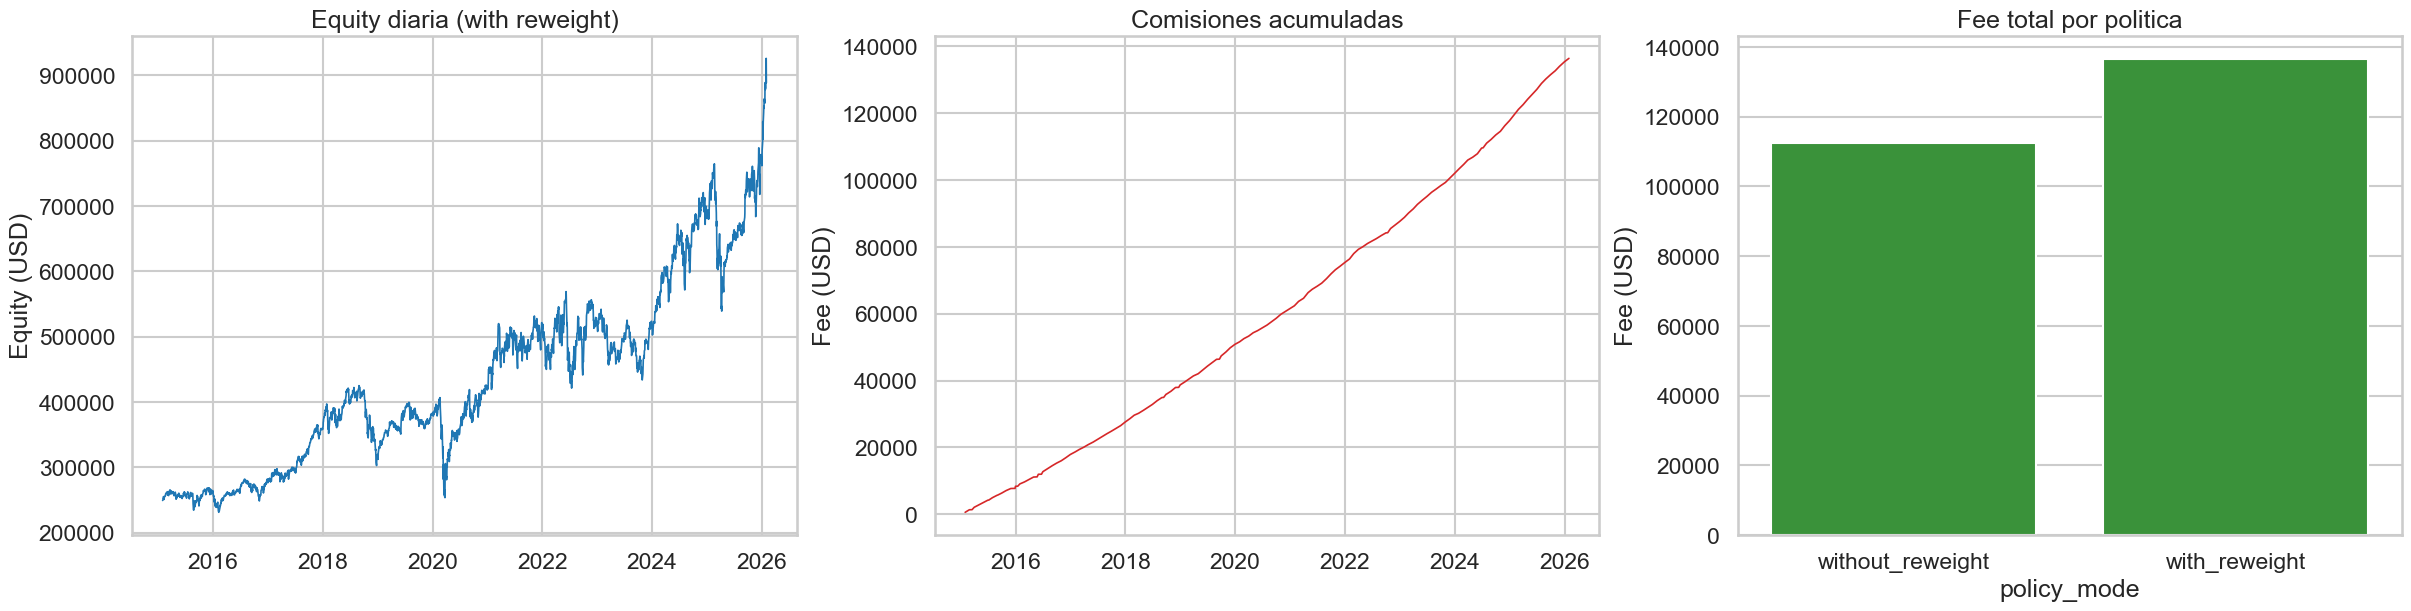


  NOTEBOOK 4 — RESUMEN FINAL
  Controles criticos:     28/28 PASS
  Capital inicial:        $250,000
  Equity final:           $888,522.88
  Return vs capital:      255.41%
  Return desde val. 1:    256.21%
  Comisiones totales:     $136,439.95
  Ordenes filled:         3,650
  No-fill por cash:       209
  Proxy exits:            16
  Banda 4.9%-5.1%:      80.98% en rango
  ---
  Politica sin reweight:  equity $1,223,675.25, fee $112,581.11
  Delta fee reweight:     $+23,858.83
  STATUS: PASS — Pipeline listo para Notebook 5.


In [7]:
# Exportes
orders_df.to_csv(OUT_ORDERS, index=False)
portfolio_daily_df.to_csv(OUT_DAILY, index=False)
rebalance_summary_df.to_csv(OUT_REBALANCE, index=False)
cost_summary_df.to_csv(OUT_COSTS, index=False)
pd.DataFrame(checks).to_csv(OUT_CHECKS, index=False)

artifacts = {
    "n4_orders_log.csv":         OUT_ORDERS,
    "n4_portfolio_daily.csv":    OUT_DAILY,
    "n4_rebalance_summary.csv":  OUT_REBALANCE,
    "n4_cost_summary.csv":       OUT_COSTS,
    "n4_checks.csv":             OUT_CHECKS,
}

def file_exists_and_size(path):
    try:
        with open(path, "rb") as f:
            f.seek(0, 2)
            return True, f.tell()
    except OSError:
        return False, 0

print("Artefactos exportados:")
artifact_ok = {}
for name, path in artifacts.items():
    exists, size = file_exists_and_size(path)
    artifact_ok[name] = exists
    print(f"  {'ok' if exists else 'FALTA':>5}  {size:>12,} bytes  {name}")

fail_if(not all(artifact_ok.values()), "Faltan artefactos.")


# --- Graficos de control ---
fig, axes = plt.subplots(1, 3, figsize=(24, 6), constrained_layout=True)

axes[0].plot(portfolio_daily_df["date"], portfolio_daily_df["equity"], linewidth=1.2, color="#1f77b4")
axes[0].set_title("Equity diaria (with reweight)")
axes[0].set_ylabel("Equity (USD)")

if len(filled_orders) > 0:
    fee_curve = (filled_orders.sort_values("date")
                 .groupby("date", observed=True)["fee"].sum().cumsum()
                 .rename("cum_fee").reset_index())
else:
    fee_curve = pd.DataFrame({"date": portfolio_daily_df["date"], "cum_fee": 0.0})
axes[1].plot(fee_curve["date"], fee_curve["cum_fee"], linewidth=1.2, color="#d62728")
axes[1].set_title("Comisiones acumuladas")
axes[1].set_ylabel("Fee (USD)")

sns.barplot(data=policy_comparison_df, x="policy_mode", y="total_fee", ax=axes[2], color="#2ca02c")
axes[2].set_title("Fee total por politica")
axes[2].set_ylabel("Fee (USD)")
plt.show()

# --- Excepciones operativas ---
n_no_fill = int((orders_df["status"] == "no_fill_cash").sum()) if len(orders_df) else 0
n_proxy = int(orders_df.loc[
    (orders_df["reason"] == "forced_exit_no_quote_proxy") & (orders_df["status"] == "filled")
].shape[0]) if len(orders_df) else 0

# --- Resumen final ---
with_row = policy_comparison_df.loc[policy_comparison_df["policy_mode"] == "with_reweight"].iloc[0]
without_row = policy_comparison_df.loc[policy_comparison_df["policy_mode"] == "without_reweight"].iloc[0]

print()
print("=" * 60)
print("  NOTEBOOK 4 — RESUMEN FINAL")
print("=" * 60)
print(f"  Controles criticos:     {n_pass}/{n_crit} PASS")
print(f"  Capital inicial:        ${initial_capital:,.0f}")
print(f"  Equity final:           ${with_row['final_equity']:,.2f}")
print(f"  Return vs capital:      {with_row['return_vs_initial_capital']:.2%}")
print(f"  Return desde val. 1:    {with_row['return_from_first_valuation']:.2%}")
print(f"  Comisiones totales:     ${with_row['total_fee']:,.2f}")
print(f"  Ordenes filled:         {int(with_row['n_filled_orders']):,}")
print(f"  No-fill por cash:       {n_no_fill}")
print(f"  Proxy exits:            {n_proxy}")
print(
    "  Banda 4.9%-5.1%:      "
    f"{weight_band_summary_df['band_coverage'].iloc[0]:.2%} en rango"
)
print(f"  ---")
print(f"  Politica sin reweight:  equity ${without_row['final_equity']:,.2f}, fee ${without_row['total_fee']:,.2f}")
print(f"  Delta fee reweight:     ${with_row['total_fee'] - without_row['total_fee']:+,.2f}")
print("=" * 60)
if n_pass == n_crit:
    print("  STATUS: PASS — Pipeline listo para Notebook 5.")
else:
    print("  STATUS: FAIL — Revisar controles fallidos.")
print("=" * 60)